# 03. Prepayment Modeling - Freddie Mac SFLLD

## Summary

This notebook builds and evaluates predictive models for mortgage prepayment,
defined as a loan reaching zero balance via voluntary payoff (`zero_balance_code
== 1`, covering both sale and refinance), using the same 2018–2022 vintage
window as the default model for consistency and sample size. Key findings:

- The prepayment rate is much less rare than default (2018 vintage: ~79%
  prepaid), making this a more balanced classification problem than default
  prediction.
- Prepayment rates decline sharply across more recent vintages (79% in 2018
  to 16% in 2022), driven by two overlapping factors: right-censoring (less
  time to prepay) and a **lock-in effect** — loans originated at historically
  low 2020-2021 rates have little incentive to refinance into the higher rates
  that followed.
- Logistic Regression achieved ROC-AUC 0.633 — notably lower than the 0.763
  achieved for default prediction, suggesting prepayment is harder to predict
  from static, origination-time features alone.
- Random Forest substantially outperformed Logistic Regression (ROC-AUC 0.747
  vs. 0.633), unlike the default model where the two performed similarly —
  indicating prepayment behavior involves non-linear feature interactions that
  a linear model cannot capture.
- Feature importance confirms the lock-in effect: `original_interest_rate`
  alone accounts for 76% of predictive signal in the Random Forest model, far
  more concentrated than in the default model (where the top 3 features
  combined for ~75%).
- **Next steps:** incorporating time-varying, market-level features (e.g.,
  prevailing mortgage rates over the life of the loan, not just at origination)
  would likely improve prepayment prediction further, since refinancing
  decisions depend on the gap between a borrower's original rate and current
  market rates.

## 1. Inspect Zero Balance Code

Prepayment is defined using `zero_balance_code`, which records the reason a
loan's balance reached zero. Code `01` indicates the loan was prepaid or
matured. Before building a label, inspect the distribution of this field to
confirm how many loans were prepaid vs. still active vs. terminated for other
reasons (e.g., foreclosure).

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data_loader import load_orig_data, clean_orig_data, load_svcg_data

df_svcg_2018 = load_svcg_data(2018)

print(df_svcg_2018['zero_balance_code'].value_counts(dropna=False))

zero_balance_code
NaN     1959030
1.0       39468
96.0        115
16.0         53
2.0          28
9.0          15
15.0         12
3.0           7
Name: count, dtype: int64


## 2. Define Prepayment Label

Following the same pattern as the default label, aggregate `zero_balance_code`
to the loan level: a loan is flagged as prepaid if it was ever recorded with
code `01` (Prepaid or Matured). As with the default label, this is subject to
the same right-censoring concern for recent vintage years — loans need time to
either prepay or not, so the same 2018–2022 restriction will apply.

In [2]:
from data_loader import build_prepayment_dataset

df_prepay_2018 = build_prepayment_dataset(2018)

print(df_prepay_2018.shape)
print(df_prepay_2018['prepay_flag'].value_counts(normalize=True))

(50000, 35)
prepay_flag
1    0.78936
0    0.21064
Name: proportion, dtype: float64


In [5]:
# Check prepayment rate by vintage year to look for right-censoring
years = range(2018,2026)

for year in years:
    df_year = build_prepayment_dataset(year)
    rate = df_year['prepay_flag'].mean()
    print(f"{year}: {rate:.2%}")

2018: 78.94%
2019: 70.15%
2020: 36.88%
2021: 17.35%
2022: 15.99%
2023: 18.18%
2024: 9.41%
2025: 1.79%


### Note: Prepayment Rate Decline — Two Overlapping Causes

Prepayment rates decline sharply after 2020 (79% in 2018 down to <2% in 2025).
Unlike the default label, this decline likely reflects two distinct factors:

1. **Right-censoring:** More recently originated loans have had less time to
   either sell or refinance.
2. **Rate environment ("lock-in effect"):** Loans originated in 2020-2021
   carry historically low interest rates (often below 3%). Since rates rose
   sharply afterward, these borrowers have little financial incentive to
   refinance — even loans with several years of observation history show low
   prepayment because refinancing would mean moving to a *higher* rate.

This means the vintage-year cutoff decision here is less clean than it was
for the default label. A vintage year like 2021 may show a "true" low
prepayment rate (driven by lock-in) rather than a purely censored one.

### Decision: Use 2018–2022 Vintages (Consistent with Default Model)

Despite the lock-in effect complicating interpretation, the 2018–2022 window
is used here for two reasons: (1) consistency with the default model's vintage
cutoff, and (2) sample size — restricting to 2018–2019 alone would leave only
~100,000 loans, compared to ~250,000 across 2018–2022. The lock-in effect
means prepayment rates for 2020–2022 vintages should be interpreted as a
mix of "true" low prepayment propensity and censoring, rather than a clean
signal — this is an important caveat for interpreting model results,
particularly feature importance related to interest rate.

In [6]:
years = range(2018,2023)

prepay_df_list = []

for year in years:
    df_year = build_prepayment_dataset(year)
    prepay_df_list.append(df_year)

df_all_prepay = pd.concat(prepay_df_list, ignore_index=True)

print(df_all_prepay.shape)
print(df_all_prepay.groupby('vintage_year')['prepay_flag'].mean())

(250000, 35)
vintage_year
2018    0.78936
2019    0.70146
2020    0.36884
2021    0.17346
2022    0.15994
Name: prepay_flag, dtype: float64


## 3. Train/Test Split and Baseline Logistic Regression

Following the same approach as the default model: select numeric origination
features, split into train/test sets (stratified on the target), scale
features, and train a baseline Logistic Regression model to predict
`prepay_flag`.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

features = [
    'credit_score', 'original_cltv', 'original_dti', 'original_upb',
    'original_ltv', 'original_interest_rate', 'original_loan_term',
    'number_of_borrowers', 'number_of_units'
]

target = 'prepay_flag'

df_baseline_prepay = df_all_prepay[features + [target]].dropna()

X = df_baseline_prepay[features]
y = df_baseline_prepay[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (Logistic Regression is sensitive to feature scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_prepay = LogisticRegression(max_iter=1000)
model_prepay.fit(X_train_scaled, y_train)

y_pred_proba_prepay = model_prepay.predict_proba(X_test_scaled)[:,1]
y_pred_prepay = model_prepay.predict(X_test_scaled)

print(classification_report(y_test, y_pred_prepay, zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_prepay):.4f}")

              precision    recall  f1-score   support

           0       0.59      0.76      0.67     28010
           1       0.52      0.32      0.40     21869

    accuracy                           0.57     49879
   macro avg       0.55      0.54      0.53     49879
weighted avg       0.56      0.57      0.55     49879

ROC-AUC: 0.6330


### Baseline Results: Prepayment Harder to Predict Than Default

The Logistic Regression baseline achieved ROC-AUC 0.633 for prepayment —
notably lower than the 0.763 achieved for default prediction. This likely
reflects a fundamental difference between the two outcomes: default is
strongly tied to borrower-specific financial characteristics (credit score,
DTI), which are well-represented in our features. Prepayment, however, is
driven heavily by external events — interest rate movements enabling
refinancing, or personal circumstances like relocation — that are not
captured by origination-time loan characteristics alone. This suggests that
improving this model would likely require incorporating time-varying,
market-level features (e.g., prevailing mortgage rates over time) rather than
just static origination features.

## 4. Random Forest Model

Train a Random Forest classifier on the same features and compare its
performance (ROC-AUC, precision/recall) against the Logistic Regression
baseline. Random Forest can capture non-linear relationships and feature
interactions that Logistic Regression cannot.

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model_prepay = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf_model_prepay.fit(X_train, y_train)

rf_pred_proba_prepay = rf_model_prepay.predict_proba(X_test)[:, 1]

print(f"Random Forest ROC-AUC: {roc_auc_score(y_test, rf_pred_proba_prepay):.4f}")
print(f"Logistic Regression ROC-AUC: {roc_auc_score(y_test, y_pred_proba_prepay):.4f}")

Random Forest ROC-AUC: 0.7469
Logistic Regression ROC-AUC: 0.6330


original_interest_rate    0.760017
original_upb              0.080321
credit_score              0.040260
original_cltv             0.037984
original_ltv              0.028846
original_loan_term        0.021231
original_dti              0.019046
number_of_units           0.006485
number_of_borrowers       0.005811
dtype: float64


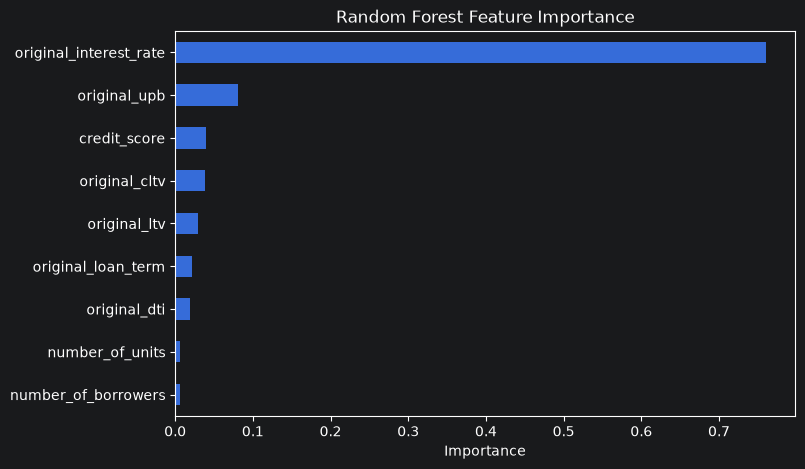

In [16]:
importances_prepay = pd.Series(rf_model_prepay.feature_importances_, index=features).sort_values(ascending=False)
print(importances_prepay)

plt.figure(figsize=(8, 5))
importances_prepay.plot(kind='barh')
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.show()

In [18]:
print(rf_pred_proba_prepay[:5])
print(y_pred_proba_prepay[:5])

[0.23764692 0.61299733 0.6710455  0.39798988 0.39983368]
[0.35283588 0.44638108 0.58671489 0.40976563 0.40560178]


### Comparison: Random Forest Substantially Outperforms Logistic Regression

Unlike the default model (where Random Forest and Logistic Regression performed
similarly), Random Forest substantially outperforms Logistic Regression for
prepayment prediction (ROC-AUC 0.747 vs. 0.633). This suggests that prepayment
behavior involves non-linear relationships or interactions between features
(e.g., interest rate combined with LTV or loan age) that Logistic Regression's
linear structure cannot capture, but Random Forest's tree-based structure can.

This is a meaningful contrast to the default model finding: for default, model
complexity didn't matter much (limited by feature/data scope); for prepayment,
model complexity clearly does matter, likely because the interest-rate-driven
lock-in effect interacts non-linearly with other loan characteristics.